# Практическое занятие 4. Прогноз температуры электропривода высотной платформы

Цель занятия - построить и сравнить простую физически
интерпретируемую модель, линейную регуляризованную модель,
случайный лес и градиентный бустинг для прогноза температуры
обмотки электродвигателя.

HAPS (High Altitude Platform Station) - высотная
псевдоспутниковая платформа. В инженерном смысле это летательный
аппарат длительного пребывания в стратосфере. Для такого объекта
тепловой режим электропривода важен из-за ограниченных запасов
массы, энергии и охлаждения.

## Инициализация среды выполнения

Ячейка ниже обеспечивает запуск блокнота в Google Colab и в
локальном Jupyter Notebook. Если проект уже открыт локально,
повторное клонирование не выполняется.

In [1]:
# COLAB_BOOTSTRAP_APPailab
from pathlib import Path
import os
import sys

REQUIRED_PROCESSED_FILES = ['practice_04_haps_thermal_features.csv', 'practice_04_haps_thermal_diagnostics.csv']
PROJECT_REPOSITORY_URL = "https://github.com/Alexflex/appailab.git"

def find_project_root(start: Path) -> Path | None:
    for candidate in [start, *start.parents]:
        if (candidate / "requirements-colab.txt").exists() and (candidate / "data" / "processed").exists():
            return candidate
    return None

project_root = find_project_root(Path.cwd())

if project_root is None:
    try:
        import google.colab  # type: ignore
        IN_COLAB = True
    except Exception:
        IN_COLAB = False

    if IN_COLAB:
        workdir = Path("/content/appailab")
        if not workdir.exists():
            !git clone -q {PROJECT_REPOSITORY_URL} {workdir}
        project_root = workdir
        os.chdir(project_root)
        !pip install -q -r requirements-colab.txt
    else:
        raise FileNotFoundError(
            "Не найден корень проекта. Откройте блокнот из репозитория appailab "
            "или выполните git clone перед запуском."
        )

sys.path.insert(0, str(project_root / "src"))
missing_files = [
    name for name in REQUIRED_PROCESSED_FILES
    if not (project_root / "data" / "processed" / name).exists()
]
if missing_files:
    raise FileNotFoundError(
        "Не найдены подготовленные CSV: " + ", ".join(missing_files)
        + ". Выполните python scripts/generate_datasets.py."
    )

print(f"Корень проекта: {project_root}")
print("Проверенные CSV:", ", ".join(REQUIRED_PROCESSED_FILES))

Корень проекта: /mnt/f/projects/appai_lab
Проверенные CSV: practice_04_haps_thermal_features.csv, practice_04_haps_thermal_diagnostics.csv


In [2]:
import math
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.cluster import DBSCAN, KMeans
from sklearn.decomposition import PCA
from sklearn.ensemble import GradientBoostingRegressor, RandomForestClassifier, RandomForestRegressor
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LinearRegression, LogisticRegression, Ridge
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    adjusted_rand_score,
    classification_report,
    confusion_matrix,
    f1_score,
    mean_absolute_error,
    mean_squared_error,
    precision_score,
    recall_score,
    r2_score,
    silhouette_score,
)
from sklearn.mixture import GaussianMixture
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", 80)
plt.rcParams["figure.figsize"] = (9, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["font.size"] = 11

DATA_DIR = project_root / "data" / "processed"
RANDOM_STATE = 20260507

## Теоретический блок

Тепловая модель первого порядка описывает инерционное изменение
температуры:

$$
T_{k+1} = T_k + \frac{\Delta t}{\tau}
\left(T_{amb,k} + R_{th} P_{loss,k} - T_k\right),
$$

где `T` - температура обмотки, `T_amb` - температура окружающей
среды, `R_th` - тепловое сопротивление, `tau` - тепловая
постоянная времени, `P_loss` - суммарные потери.

Случайный лес (Random Forest) - ансамбль деревьев решений,
усредняющий прогнозы многих деревьев. Градиентный бустинг
(Gradient Boosting) - последовательный ансамбль, в котором каждая
следующая модель уточняет ошибки предыдущих. Оба метода полезны
для нелинейных зависимостей, но требуют контроля переобучения и
осторожной интерпретации важности признаков.

In [3]:
FEATURES_FILE = DATA_DIR / "practice_04_haps_thermal_features.csv"
DIAGNOSTICS_FILE = DATA_DIR / "practice_04_haps_thermal_diagnostics.csv"

df = pd.read_csv(FEATURES_FILE)
diagnostics_df = pd.read_csv(DIAGNOSTICS_FILE)
full_df = df.merge(diagnostics_df, on="sample_id", validate="one_to_one")

display(df.head())
print("Размер feature-таблицы:", df.shape)
print("Размер diagnostics-таблицы:", diagnostics_df.shape)

,sample_id,profile_id,time_s,altitude_m,air_density_kg_m3,ambient_temp_c,cooling_air_speed_mps,speed_rpm,torque_nm,voltage_v,current_a,winding_temp_c
0,1,1,0.0,1932.0,0.97594,1.067,52.810,3561.4,8.49026,352.578,10.1634,37.131
1,2,1,5.0,1944.5,0.97451,2.319,50.039,3467.6,11.33015,272.858,16.9944,37.276
2,3,1,10.0,2044.9,0.96306,1.740,49.764,3655.1,10.25674,269.380,16.6121,36.985
3,4,1,15.0,2074.9,0.95968,3.118,49.592,3774.2,10.43901,539.839,8.7801,38.584
4,5,1,20.0,2246.7,0.94047,1.841,51.970,3985.7,11.11826,348.354,14.9435,40.445


Размер feature-таблицы: (720, 12)
Размер diagnostics-таблицы: (720, 13)


## Паспорт набора данных

`feature-CSV` содержит только признаки, допустимые для базового
моделирования, и целевую переменную `winding_temp_c`.
`diagnostics-CSV` содержит расчетные тепловые величины:
суммарные потери, тепловое сопротивление, постоянную времени,
стационарную температуру и запас до теплового предела.

В базовую модель запрещено автоматически включать
`steady_state_temp_c`, `temperature_margin_c` и `is_overheated`,
так как эти столбцы прямо раскрывают способ формирования тепловой
цели или ее ограничений.

In [4]:
display(df.describe().T)
print("Пропуски по столбцам:")
display(df.isna().sum().to_frame("missing_count"))
print("Диапазон температуры обмотки:")
display(df["winding_temp_c"].describe())

,count,mean,std,min,25%,50%,75%,max
sample_id,720.0,360.500000,207.990384,1.00000,180.750000,360.50000,540.250000,720.00000
profile_id,720.0,3.500000,1.709012,1.00000,2.000000,3.50000,5.000000,6.00000
time_s,720.0,297.500000,173.319469,0.00000,148.750000,297.50000,446.250000,595.00000
altitude_m,720.0,10501.875000,5825.515095,1446.50000,5419.275000,10522.80000,15627.175000,19668.40000
air_density_kg_m3,720.0,0.445426,0.289854,0.12112,0.194843,0.35799,0.647505,1.03331
ambient_temp_c,720.0,-39.014837,22.919971,-58.00000,-58.000000,-53.02550,-20.357000,7.05700
cooling_air_speed_mps,720.0,33.087786,10.010877,18.88200,24.732250,30.19900,40.087500,55.38000
speed_rpm,720.0,4525.403472,717.161844,2908.20000,3984.075000,4482.35000,5050.950000,6148.50000
torque_nm,720.0,13.608003,2.979569,7.29713,11.349540,13.44962,15.748900,21.16236
voltage_v,720.0,375.382019,104.282378,265.29200,272.215000,349.73650,536.622750,545.71700


Пропуски по столбцам:


,missing_count
sample_id,0
profile_id,0
time_s,0
altitude_m,0
air_density_kg_m3,0
ambient_temp_c,0
cooling_air_speed_mps,0
speed_rpm,0
torque_nm,0
voltage_v,0


Диапазон температуры обмотки:


count    720.000000
mean      40.828106
std        7.736299
min       27.342000
25%       35.103750
50%       39.814500
75%       45.861750
max       66.784000
Name: winding_temp_c, dtype: float64

## Разведочный анализ данных

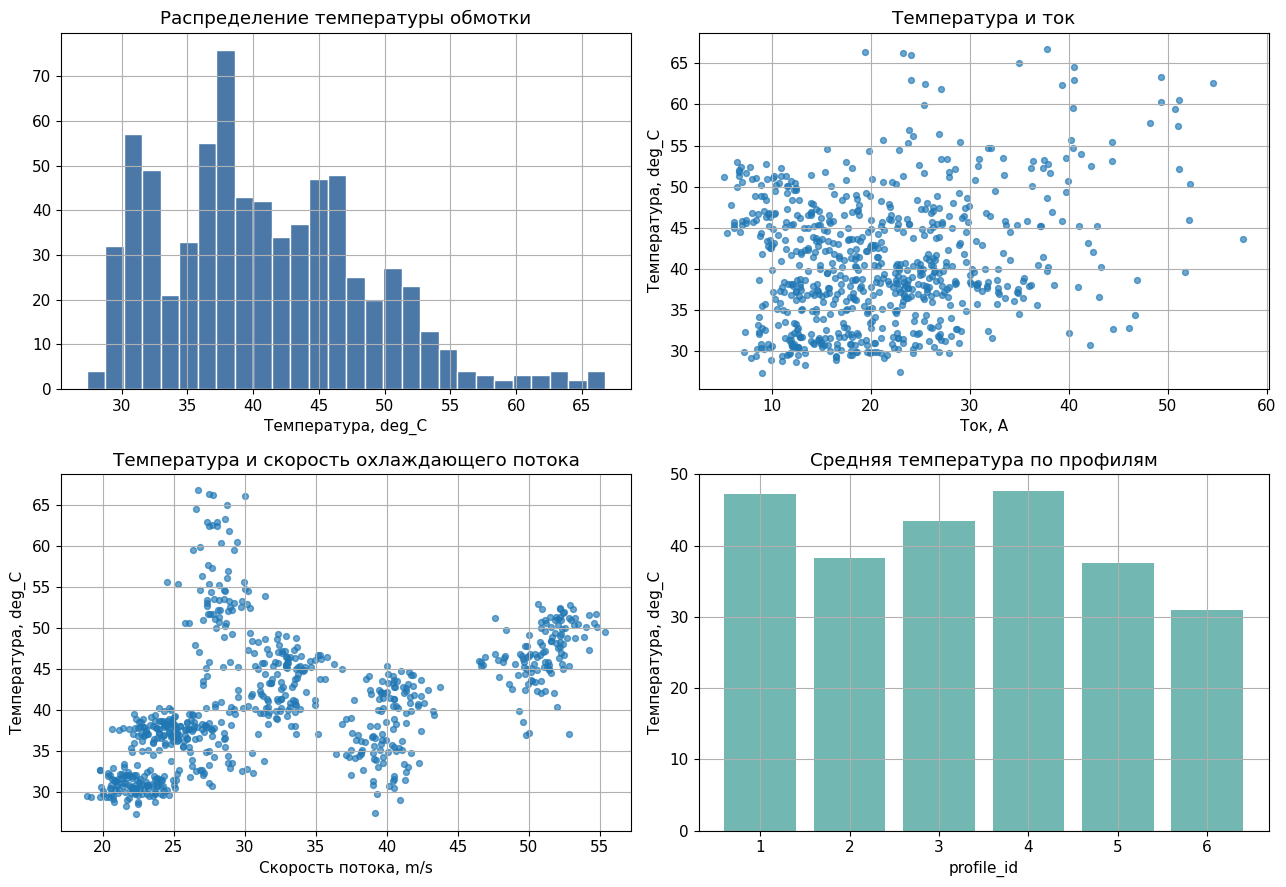

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
axes = axes.ravel()

axes[0].hist(df["winding_temp_c"], bins=28, color="#4c78a8", edgecolor="white")
axes[0].set_title("Распределение температуры обмотки")
axes[0].set_xlabel("Температура, deg_C")

axes[1].scatter(df["current_a"], df["winding_temp_c"], alpha=0.65, s=18)
axes[1].set_title("Температура и ток")
axes[1].set_xlabel("Ток, A")
axes[1].set_ylabel("Температура, deg_C")

axes[2].scatter(df["cooling_air_speed_mps"], df["winding_temp_c"], alpha=0.65, s=18)
axes[2].set_title("Температура и скорость охлаждающего потока")
axes[2].set_xlabel("Скорость потока, m/s")
axes[2].set_ylabel("Температура, deg_C")

profile_means = df.groupby("profile_id")["winding_temp_c"].mean()
axes[3].bar(profile_means.index.astype(str), profile_means.values, color="#72b7b2")
axes[3].set_title("Средняя температура по профилям")
axes[3].set_xlabel("profile_id")
axes[3].set_ylabel("Температура, deg_C")

plt.tight_layout()
plt.show()

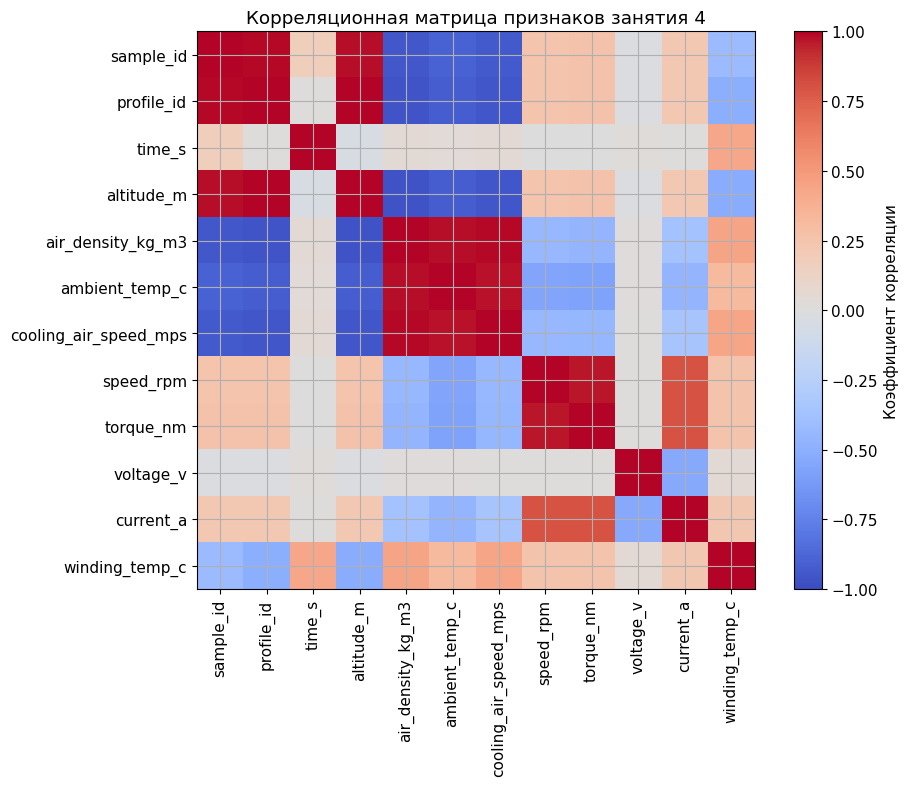

In [6]:
numeric_columns = df.select_dtypes(include=[np.number]).columns
corr = df[numeric_columns].corr(numeric_only=True)
fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr.columns)))
ax.set_yticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=90)
ax.set_yticklabels(corr.columns)
fig.colorbar(im, ax=ax, label="Коэффициент корреляции")
ax.set_title("Корреляционная матрица признаков занятия 4")
plt.tight_layout()
plt.show()

## Выбор признаков и разбиение выборки

Для начального занятия используется случайное разбиение с
сохранением доли каждого `profile_id` в обучающей и тестовой
выборках. Это упрощает сравнение моделей. В задачах строгого
прогнозирования временных рядов следует дополнительно проверять
групповое или хронологическое разбиение, чтобы соседние точки
одного испытания не создавали утечку информации.

In [7]:
thermal_features = ['altitude_m', 'air_density_kg_m3', 'ambient_temp_c', 'cooling_air_speed_mps', 'speed_rpm', 'torque_nm', 'voltage_v', 'current_a']

target_column = "winding_temp_c"
forbidden_columns = {"winding_temp_c", "steady_state_temp_c", "temperature_margin_c", "is_overheated"}
leaked = forbidden_columns.intersection(thermal_features)
if leaked:
    raise ValueError(f"Обнаружена утечка данных: {sorted(leaked)}")

train_idx, test_idx = train_test_split(
    df.index,
    test_size=0.25,
    random_state=RANDOM_STATE,
    stratify=df["profile_id"],
)

X_train = df.loc[train_idx, thermal_features]
X_test = df.loc[test_idx, thermal_features]
y_train = df.loc[train_idx, target_column]
y_test = df.loc[test_idx, target_column]

print("Train:", X_train.shape, "Test:", X_test.shape)
display(df.loc[test_idx, "profile_id"].value_counts().sort_index().to_frame("test_count"))

Train: (540, 8) Test: (180, 8)


,test_count
profile_id,
1,30
2,30
3,30
4,30
5,30
6,30


## Простая физически мотивированная модель

Физически мотивированная модель не является строгой тепловой
симуляцией. Она использует приближенный признак потерь, рассчитанный
из доступных измерений:

$$
P_{loss,proxy} = U I - M \omega.
$$

Далее линейная регрессия оценивает связь температуры с
температурой окружающей среды, прокси-потерями и охлаждением.

In [8]:
def make_physics_features(data: pd.DataFrame) -> pd.DataFrame:
    omega = 2.0 * np.pi * data["speed_rpm"] / 60.0
    loss_proxy = data["voltage_v"] * data["current_a"] - data["torque_nm"] * omega
    return pd.DataFrame(
        {
            "ambient_temp_c": data["ambient_temp_c"],
            "loss_proxy_w": loss_proxy,
            "cooling_inverse": 1.0 / np.sqrt(data["cooling_air_speed_mps"].clip(lower=1.0)),
        },
        index=data.index,
    )

physics_model = LinearRegression()
physics_model.fit(make_physics_features(df.loc[train_idx]), y_train)
physics_pred = physics_model.predict(make_physics_features(df.loc[test_idx]))

## Обучение моделей машинного обучения

In [9]:
models = {
    "physics_proxy_linear": physics_model,
    "ridge": Pipeline(
        [
            ("scaler", StandardScaler()),
            ("model", Ridge(alpha=1.0)),
        ]
    ),
    "random_forest": RandomForestRegressor(
        n_estimators=250,
        max_depth=8,
        min_samples_leaf=4,
        random_state=RANDOM_STATE,
    ),
    "gradient_boosting": GradientBoostingRegressor(
        n_estimators=180,
        learning_rate=0.045,
        max_depth=3,
        random_state=RANDOM_STATE,
    ),
}

predictions = {"physics_proxy_linear": physics_pred}
for name, model in models.items():
    if name == "physics_proxy_linear":
        continue
    model.fit(X_train, y_train)
    predictions[name] = model.predict(X_test)

metrics_rows = []
for name, pred in predictions.items():
    metrics_rows.append(
        {
            "model": name,
            "MAE_deg_C": mean_absolute_error(y_test, pred),
            "RMSE_deg_C": np.sqrt(mean_squared_error(y_test, pred)),
            "R2": r2_score(y_test, pred),
        }
    )
metrics_df = pd.DataFrame(metrics_rows).sort_values("RMSE_deg_C")
display(metrics_df)

,model,MAE_deg_C,RMSE_deg_C,R2
2,random_forest,1.766243,3.133668,0.827460
3,gradient_boosting,1.971802,3.316700,0.806716
1,ridge,3.493948,5.130995,0.537419
0,physics_proxy_linear,4.342645,5.914980,0.385261


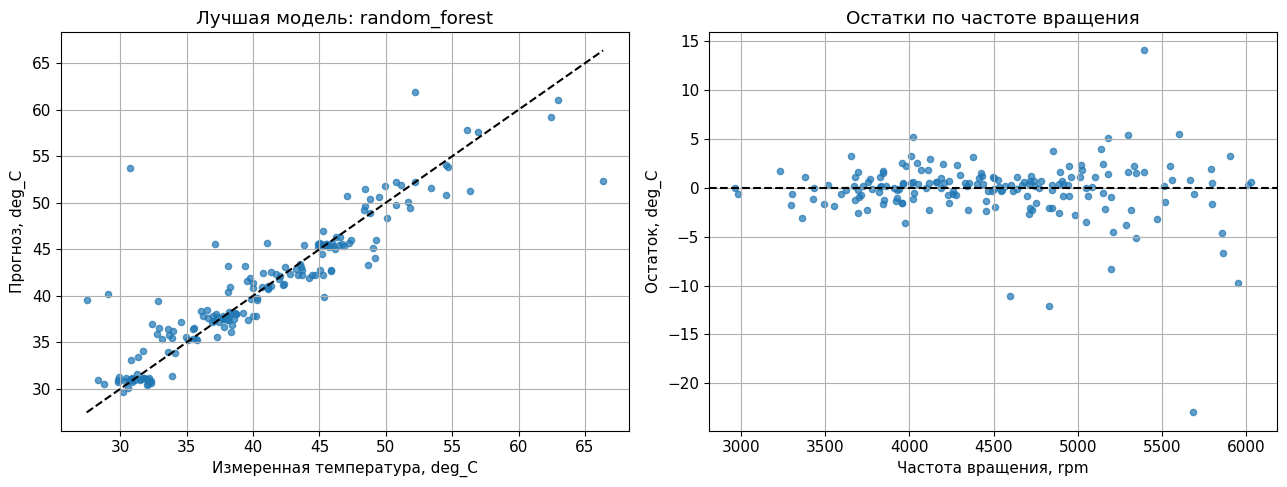

In [10]:
best_model_name = metrics_df.iloc[0]["model"]
best_pred = predictions[best_model_name]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].scatter(y_test, best_pred, alpha=0.70, s=20)
lims = [min(y_test.min(), best_pred.min()), max(y_test.max(), best_pred.max())]
axes[0].plot(lims, lims, color="black", linestyle="--")
axes[0].set_xlabel("Измеренная температура, deg_C")
axes[0].set_ylabel("Прогноз, deg_C")
axes[0].set_title(f"Лучшая модель: {best_model_name}")

residuals = y_test - best_pred
axes[1].scatter(df.loc[test_idx, "speed_rpm"], residuals, alpha=0.70, s=20)
axes[1].axhline(0.0, color="black", linestyle="--")
axes[1].set_xlabel("Частота вращения, rpm")
axes[1].set_ylabel("Остаток, deg_C")
axes[1].set_title("Остатки по частоте вращения")
plt.tight_layout()
plt.show()

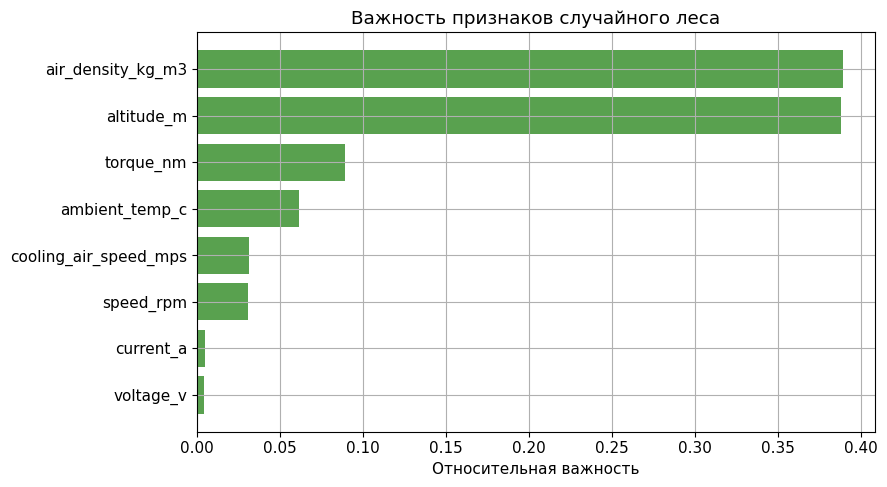

,feature,importance
1,air_density_kg_m3,0.389183
0,altitude_m,0.388409
5,torque_nm,0.089488
2,ambient_temp_c,0.061329
3,cooling_air_speed_mps,0.031140
4,speed_rpm,0.031089
7,current_a,0.004963
6,voltage_v,0.004397


In [11]:
rf_model = models["random_forest"]
importance_df = pd.DataFrame(
    {
        "feature": thermal_features,
        "importance": rf_model.feature_importances_,
    }
).sort_values("importance", ascending=True)

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(importance_df["feature"], importance_df["importance"], color="#59a14f")
ax.set_title("Важность признаков случайного леса")
ax.set_xlabel("Относительная важность")
plt.tight_layout()
plt.show()

display(importance_df.sort_values("importance", ascending=False))

## Демонстрация утечки данных

> **Внимание. АНТИПРИМЕР - НЕ ИСПОЛЬЗОВАТЬ КАК РАБОЧУЮ МОДЕЛЬ.**
> В следующей ячейке в признаки намеренно добавляется
> `steady_state_temp_c`. Этот столбец рассчитан из скрытой
> физической модели генератора и поэтому является диагностической
> подсказкой, а не обычным измеряемым признаком.

In [12]:
leakage_df = df.merge(
    diagnostics_df[["sample_id", "steady_state_temp_c", "temperature_margin_c"]],
    on="sample_id",
    validate="one_to_one",
)
leakage_features = thermal_features + ["steady_state_temp_c"]

X_train_leak = leakage_df.loc[train_idx, leakage_features]
X_test_leak = leakage_df.loc[test_idx, leakage_features]
leakage_model = RandomForestRegressor(
    n_estimators=250,
    max_depth=8,
    min_samples_leaf=4,
    random_state=RANDOM_STATE,
)
leakage_model.fit(X_train_leak, y_train)
leakage_pred = leakage_model.predict(X_test_leak)
print("R2 строгой лучшей модели:", round(float(metrics_df.iloc[0]["R2"]), 4))
print("R2 модели с утечкой:", round(r2_score(y_test, leakage_pred), 4))

R2 строгой лучшей модели: 0.8275
R2 модели с утечкой: 0.8294


## Самостоятельный эксперимент

In [13]:
experiment_max_depth = 6

experiment_model = RandomForestRegressor(
    n_estimators=160,
    max_depth=experiment_max_depth,
    min_samples_leaf=4,
    random_state=RANDOM_STATE,
)
experiment_model.fit(X_train, y_train)
experiment_pred = experiment_model.predict(X_test)
print("MAE:", round(mean_absolute_error(y_test, experiment_pred), 3))
print("RMSE:", round(np.sqrt(mean_squared_error(y_test, experiment_pred)), 3))
print("R2:", round(r2_score(y_test, experiment_pred), 4))

MAE: 1.936
RMSE: 3.258
R2: 0.8135


## Задание для отчета

1. Объясните, почему разбиение выполнено по профилям, а не
   случайным перемешиванием строк.
2. Сравните физически мотивированную модель, Ridge-регрессию,
   случайный лес и градиентный бустинг.
3. Укажите две наиболее важные величины для прогноза температуры.
4. Объясните, почему важность признака в случайном лесе не равна
   строгой физической причинности.
5. Опишите антипример утечки данных и не используйте его метрики
   как основной результат.

Открытые источники для расширения: NASA C-MAPSS Aircraft Engine
Simulator Data и открытые наборы температурного моделирования
электромеханических систем. Их следует применять только после
отдельной проверки структуры временных рядов и правил разбиения.